# Before you start
**We have to change the version of python in your collab runtime**
**Runtime -> Change runtime type -> Runtime version -> 2026.07**
* Make sure you read all the text. It is easy to click and play, but answering the questions is where the real learning happens.
* Try playing around with different parameter settings and variables to make sure you really understand what is happening.
* If you are an advanced user, consider adapting the methods to your own data. You can download the tutorials locally to avoid having your data on a Google server ;)**


-----
# Longitudinal Modelling
In this tutorial, we will use our knowledge of the cross-sectional normative models to conduct longitudinal analyses. Longitudinal normative models aim to quantify longitudinal changes in neuroimaging data relative to healthy ageing trajectories.

-----

## Let's begin!
 To date, two approaches for analysing longitudinal data have been proposed within the normative modelling framework:

### The z-diff score

- The [z-diff score](https://elifesciences.org/articles/95823) [1] was developped specifically to be used with the pre-trained Bayesian Linear Regression normative models [2, 3]. The expected dataset consists of longitudinal structural MRI data from patients and healthy controls, with cortical thickness extracted using FreeSurfer, also documented in the original publication [1].

-----
### The z-gain score

- The [z-gain score](https://arxiv.org/abs/2601.07591) (sometime also referred to as the velocity-based model) [4], is a generalised way of how to model the difference between the two z-scores. It is generalisible and can be used with any normative model, as long as the correlation between the visits is known. Additonally is has a usefule forecasting feature, however, that one is beyond the scope of this tutorial.
-----

*Note*

Neither approach is strictly longitudinal in the sense where the two visits would be modelled together. Both methods require estimation of the cross-sectional models, so the pre-processing and model estimation is identical.

-----
** References
- [1] Rehak Buckova, Barbora, et al. "Using normative models pre-trained on cross-sectional data to evaluate intra-individual longitudinal changes in neuroimaging data." Elife 13 (2025): RP95823.
- [2] Fraza, Charlotte J., et al. "Warped Bayesian linear regression for normative modelling of big data." NeuroImage 245 (2021): 118715.
- [3] Rutherford, Saige, et al. "Charting brain growth and aging at high spatial precision." elife 11 (2022): e72904.
- [4] Bayer, Johamma et al. "Charting the velocity of brain growth and development." arxiv (2026)

# Setting up the environment

First, if necessary, we re-install PCNtoolkit.

The latest version of PCNtoolkit includes several updates and new features compared with previous versions. If you have used normative modelling before, we recommend familiarising yourself with the updated syntax and functionality.

For a deeper dive into the theoretical background, see the [protocol update](https://www.biorxiv.org/content/10.64898/2026.02.17.706268v2.full).

! Technical note, During the installation, you will be notified about potential future incompatibilities with ArviZ, this is okay, you can proceed with the code

In [1]:
%%capture
# Clone the latest version of the tutorial
!git clone --branch 2026 https://github.com/CharFraza/CPC_ML_tutorial.git

# Install the PCN toolkit
!pip install pcntoolkit==1.3.0

# And additional packages
! pip install nilearn

Cloning into 'CPC_ML_tutorial'...
remote: Enumerating objects: 672, done.
remote: Counting objects: 100% (196/196), done.
remote: Compressing objects: 100% (148/148), done.
remote: Total 672 (delta 114), reused 81 (delta 43), pack-reused 476 (from 1)
Receiving objects: 100% (672/672), 40.68 MiB | 9.96 MiB/s, done.
Resolving deltas: 100% (328/328), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.6/120.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.0/626.0 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 7.3.0 which is incompatible.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.16.1 which is incompatible.

In [2]:
# Import necessary packages
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os

import nilearn.plotting as plotting
from matplotlib.colors import ListedColormap

# Prepare colormap for plotting
poster_reds = ['#E9E9E9', '#FDECF2', '#FCD9E6', '#FAC6D9', '#F9B4CD', '#F7A1C0', '#F68EB4', '#F47BA7', '#F3689B', '#F1558E', '#F04282', '#EE2F75', '#ED1D69', '#D81159']
poster_reds = ListedColormap(poster_reds, 'indexed')
poster_reds_r = ListedColormap(poster_reds.colors[::-1])
poster_blues_r = ['#218380', '#25938F', '#29A39F', '#2DB4AF', '#31C4BF', '#3BCEC9', '#5CD6D2', '#7CDEDB', '#9DE7E4', '#ADEBE9', '#BEEFED', '#CEF3F2', '#DEF7F6', '#E9E9E9']
poster_blues_r = ListedColormap(poster_blues_r, 'indexed')
poster_blues = ListedColormap(poster_blues_r.colors[::-1])

poster_blue_pink_palette_normal = ListedColormap([*poster_blues.colors,*poster_reds_r.colors])

Now, we configure the locations in which the data are stored.

**Notes:**
- The data are assumed to be in .CSV format and will be loaded as pandas dataframes
- Generally the raw data will be in a different location to the analysis
- The data can have several columns/covariates but some are required by the script, i.e. 'age', 'sex' and 'site', plus the phenotypes you wish to estimate

In [3]:
# where the analysis takes place
root_dir = '/content/CPC_ML_tutorial'
!cd '/content/CPC_ML_tutorial'

data_dir = os.path.join(root_dir, 'data')

out_dir = os.path.join(root_dir, 'models', 'longitudinal')

# create the output directory if it does not already exist
os.makedirs(out_dir, exist_ok=True)

Load the longitudinal data

In [4]:
# load the longitudinal data
try:
    df = pd.read_csv("/content/CPC_ML_tutorial/data/LNM_data.csv")
except FileNotFoundError:
    print("File not found")

df.describe()

,age,lh_G&S_frontomargin_thickness,lh_G&S_occipital_inf_thickness,lh_G&S_paracentral_thickness,lh_G&S_subcentral_thickness,lh_G&S_transv_frontopol_thickness,lh_G&S_cingul-Ant_thickness,lh_G&S_cingul-Mid-Ant_thickness,lh_G&S_cingul-Mid-Post_thickness,lh_G_cingul-Post-dorsal_thickness,...,Right-Accumbens-area,Right-VentralDC,Right-vessel,Right-choroid-plexus,SubCortGrayVol,TotalGrayVol,SupraTentorialVol,SupraTentorialVolNotVent,EstimatedTotalIntraCranialVol,visit
count,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,...,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,3.300000e+02,3.300000e+02,3.300000e+02,330.000000
mean,29.351506,2.324761,2.393894,2.520776,2.671158,2.509967,2.665530,2.606042,2.534994,2.670512,...,631.609394,4395.611818,84.349394,1027.436970,63135.810510,682914.333802,1.031154e+06,1.009945e+06,1.599066e+06,1.500000
std,7.711299,0.122534,0.136400,0.129510,0.129045,0.124676,0.104851,0.135919,0.112216,0.133070,...,85.994449,420.457935,30.076455,206.075085,5110.498663,64636.677509,1.052995e+05,1.029850e+05,1.689117e+05,0.500759
min,18.052000,1.996000,1.978000,2.145000,2.402000,2.099000,2.215000,2.255000,2.239000,2.299000,...,432.100000,3368.800000,19.500000,514.800000,50837.744223,519746.966112,7.525749e+05,7.386196e+05,1.262103e+06,1.000000
25%,22.683000,2.249000,2.297000,2.443000,2.578000,2.433250,2.590500,2.519000,2.453500,2.580250,...,571.425000,4052.300000,64.450000,883.450000,59574.811589,636965.529664,9.484221e+05,9.313207e+05,1.460046e+06,1.000000
50%,28.370000,2.315500,2.396500,2.529500,2.663500,2.517000,2.665000,2.606000,2.527500,2.657500,...,631.200000,4390.100000,80.550000,994.900000,63126.405034,679366.465044,1.019905e+06,1.000600e+06,1.603637e+06,1.500000
75%,34.250000,2.404000,2.489750,2.605500,2.761750,2.586750,2.730000,2.693750,2.615000,2.755000,...,684.350000,4689.425000,100.200000,1172.700000,66715.899980,724746.167021,1.100884e+06,1.079135e+06,1.735659e+06,2.000000
max,54.933000,2.694000,2.790000,2.867000,3.019000,2.856000,3.014000,3.066000,2.877000,3.041000,...,971.200000,5494.400000,197.100000,1608.300000,76924.951824,863301.299368,1.308998e+06,1.291249e+06,2.016119e+06,2.000000


<Axes: xlabel='age', ylabel='Count'>

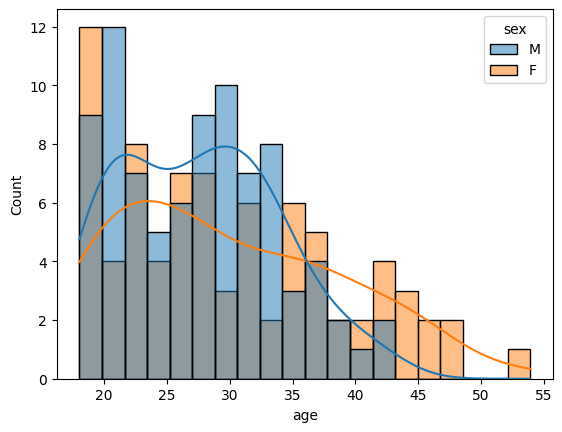

In [5]:
# plot an overview of the demographics
sns.histplot(data=df[df['visit']==1], x='age', bins=20, hue = 'sex', kde= True)

### Task

Unlike in the first tutorial, we now have two visits.
- Q. What quality control checks would you design to check if the data is appropriate for modelling?
----

## Prepare the pretrained normative models

This part is identical for both Z-diff and velocity models

### Download and unzip the pretrained normative models

In this stage, it is necessary to download the pre-trained normative models stored on surfdrive: https://surfdrive.surf.nl/s/Mb6mZyFmJeCaPcZ?dir=/zip and save them in a local folder. The folder contains a plethora of pretraned models.

Let’s break down what these filenames mean:
- BLRw: Bayesian Linear Regression model [Fraza et al.](https://doi-org.ru.idm.oclc.org/10.1016/j.neuroimage.2021.118715)
- HBR_Sb: Hierarchical Bayesian Regression model using a SHASH likelihood [de Boer et al., 2024](https://doi-org.ru.idm.oclc.org/10.1162/imag_a_00132)
- ct: cortical thickness
- fa: fractional anisotropy
- sc: subcortical measures
- DES: Destrieux atlas parcellation
- DK: Desikan–Killiany atlas parcellation
- 67K / 79K / 24K: number of subjects used to train the model
- 89sites / 100sites / 19sites: number of sites in the training dataset

Here, we will use `BLRw_ct_DES_lifespan_67K_89sites` as this parcellation is consistent with the one in our data. Download and extract the model into a separate directory.

In [6]:
import requests, zipfile, os

# Define the WebDAV URL and authentication credentials for Surfdrive to pull the model files from
BASE_URL    = "https://surfdrive.surf.nl/public.php/webdav/zip/"
SHARE_TOKEN = "Mb6mZyFmJeCaPcZ"
MODEL_NAME  = "BLRw_ct_DES_lifespan_67K_89sites"

model_dir = os.path.join(data_dir, MODEL_NAME)
zip_path  = os.path.join(data_dir, MODEL_NAME + ".zip")

os.makedirs(data_dir, exist_ok=True)

# download if not already on disk
if not os.path.exists(zip_path):
    print(f"Downloading {MODEL_NAME}...")
    r = requests.get(BASE_URL + MODEL_NAME + ".zip", auth=(SHARE_TOKEN, ""), stream=True)
    with open(zip_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
    print("Done.")
else:
    print(f"{MODEL_NAME} already downloaded, skipping.")

# unzip if not already extracted
if not os.path.exists(model_dir):
    print("Unzipping...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(model_dir)
    print("Done.")
else:
    print(f"{MODEL_NAME} already extracted, skipping.")

Done.
Unzipping...
Done.


### Load the pretrained model
Next, we load the pretrained model and disable saving of results, plots, and the model itself, as we are only interested in the predictions.


In [7]:
import pcntoolkit as ptk

# create the directory for the results
results_dir = os.path.join("models","longitudinal","results")
os.makedirs(results_dir, exist_ok=True)

# load the pretrained normative model
model = ptk.NormativeModel.load(model_dir)
model.save_dir = results_dir
model.savemodel = False
model.saveresults = False
model.saveplots = False

/usr/local/lib/python3.12/dist-packages/pcntoolkit/util/output.py:296: UserWarning: Process: 278 - 2026-08-25 14:41:43 - This model was saved with PCNtoolkit v1.1.2, but you are running v1.2.0.post1. Loading this model in v1.2.0.post1...
  warnings.warn(message, category)
/usr/local/lib/python3.12/dist-packages/pcntoolkit/util/output.py:296: UserWarning: Process: 278 - 2026-08-25 14:41:43 - This model was saved with PCNtoolkit v1.1.1, but you are running v1.2.0.post1. Loading this model in v1.2.0.post1...
  warnings.warn(message, category)
/usr/local/lib/python3.12/dist-packages/pcntoolkit/util/output.py:296: UserWarning: Process: 278 - 2026-08-25 14:41:44 - This model was saved with PCNtoolkit v1.1.1, but you are running v1.2.0.post1. Loading this model in v1.2.0.post1...
  warnings.warn(message, category)
/usr/local/lib/python3.12/dist-packages/pcntoolkit/util/output.py:296: UserWarning: Process: 278 - 2026-08-25 14:41:44 - This model was saved with PCNtoolkit v1.1.2, but you are run

### Define covariates and response variables

We define the covariates, batch effects, and response variables. Only variables that are present in both the data and the pretrained model are retained as response variables.


In [8]:
# use the model's covariates and batch effects directly
subject_id = "sub_id"
covariates = model.covariates
batch_effects = list(model.unique_batch_effects.keys())
other_vars = ["visit", "group"]
non_respvars = [subject_id] + covariates + batch_effects + other_vars

# only keep response variables (idps) present in both the data and the model
response_vars = list(filter(lambda x: x not in non_respvars, df.columns))
response_vars = list(filter(lambda x: df[x].var() > 0, response_vars))
response_vars = list(filter(lambda x: df[x].dtype != "object", response_vars))
response_vars = list(set(model.response_vars) & set(response_vars))

print(f"Covariates: {covariates}")
print(f"Batch effects: {batch_effects}")
print(f"Number of response variables: {len(response_vars)}")
print(f"Pretrained sites: {list(model.unique_batch_effects['site'])[:5]} ... ({len(model.unique_batch_effects['site'])} total)")

Covariates: ['age']
Batch effects: ['site', 'sex']
Number of response variables: 148
Pretrained sites: ['ABCD_01', 'ABCD_02', 'ABCD_03', 'ABCD_04', 'ABCD_05'] ... (89 total)


### Prepare NormData objects

We split the data across groups and visits into separate `NormData` objects. This is not strictly necessary, however, it prevents accidental mistakes in further analyses and has a didactic purpose.

We also split the controls into an **adaptation set** (20%) used to transfer the pretrained model to the new site, and a **test set** (80%) used to estimate the healthy between-visit variance $2\sigma^2(1-\rho)$.


In [10]:
from sklearn.model_selection import train_test_split

# split controls into adaptation (20%) and test (80%) at subject level
ctrl_subjects = df[df['group'] == 'control']['sub_id'].unique()
adapt_subjects, test_ctrl_subjects = train_test_split(ctrl_subjects, test_size=0.8, random_state=42)

def make_normdata(dataframe, name):
    """Create a NormData object from a dataframe."""
    return ptk.NormData.from_dataframe(
        name=name,
        dataframe=dataframe,
        covariates=covariates,
        batch_effects=batch_effects,
        response_vars=response_vars,
        remove_Nan=True,
        remove_outliers=True,
        z_threshold=10
    )

# adaptation data: 20% of controls at V1 only
adapt = make_normdata(
    df[(df['group'] == 'control') &
       (df['visit'] == 1) &
       (df['sub_id'].isin(adapt_subjects))],
    'adapt'
)

# test controls: 80% of controls at both visits
con_v1 = make_normdata(
    df[(df['group'] == 'control') &
       (df['visit'] == 1) &
       (df['sub_id'].isin(test_ctrl_subjects))],
    'con_v1'
)
con_v2 = make_normdata(
    df[(df['group'] == 'control') &
       (df['visit'] == 2) &
       (df['sub_id'].isin(test_ctrl_subjects))],
    'con_v2'
)

# patients at both visits
pat_v1 = make_normdata(df[(df['group'] == 'patient') & (df['visit'] == 1)], 'pat_v1')
pat_v2 = make_normdata(df[(df['group'] == 'patient') & (df['visit'] == 2)], 'pat_v2')

print(f"Adaptation controls:  {adapt.sizes['observations']} subjects")
print(f"Test controls V1/V2:  {con_v1.sizes['observations']} / {con_v2.sizes['observations']} subjects")
print(f"Patients V1/V2:       {pat_v1.sizes['observations']} / {pat_v2.sizes['observations']} subjects")

TypeError: only integer scalar arrays can be converted to a scalar index

## Modelling
------
### Transfer and predict

We use the `transfer_predict` function to adapt the pretrained model to the new site using the adaptation controls, and then predict on the patient and control data. The same transferred model is used for predictions at both visits — this is important because the site-specific correction is identical at V1 and V2, and therefore cancels out in the longitudinal difference.

> ⚠️ **Note:** We use `transfer_predict` rather than `predict` directly, because the pretrained model was trained on 89 different sites and the new site must be explicitly adapted to.

In [ ]:
# transfer the pretrained model to the new site using adaptation controls (V1 only)
# and predict on patients at V1
transferred = model.transfer_predict(adapt, pat_v1)
transferred.save_dir = results_dir
transferred.savemodel = False
transferred.saveresults = False
transferred.saveplots = False

# predict on remaining datasets using the transferred model
transferred.predict(pat_v2)
transferred.predict(con_v1)
transferred.predict(con_v2)

## Pause
---------
At this stage, we conducted cross-sectional analysis for both timepoints. It is sensible to check how the reuslts look to get some general overview of how we're doing.

The most straightforward way is to check to inspect the counts of positive/negative deviations accross regions

In [ ]:
# ============================================================
# Cross-sectional: Count of positive/negative extreme deviations
# ============================================================

def count_extreme_deviations(z_data, threshold=1.96):
    """
    Count positive and negative extreme deviations per region.
    z_data: DataFrame (subjects x regions) of Z scores
    """
    counts = pd.DataFrame({
        'roi': z_data.columns,
        'n_positive': (z_data > threshold).sum().values,
        'n_negative': (z_data < -threshold).sum().values,
        'n_total': z_data.notna().sum().values
    })
    counts['pct_positive'] = 100 * counts['n_positive'] / counts['n_total']
    counts['pct_negative'] = 100 * counts['n_negative'] / counts['n_total']
    counts['pct_any'] = counts['pct_positive'] + counts['pct_negative']
    return counts.sort_values('pct_any', ascending=False)

# ============================================================
# Choose the threshold and see how the count change
threshold = 1.96

# Prepare structures for the results
visit_datasets = {1: pat_v1, 2: pat_v2}
all_visit_counts = {}
all_subject_counts = {}

for ivisit in range(1, 3):
    pat_data = visit_datasets[ivisit]

    pat_z = pd.DataFrame(
        pat_data.Z.values,
        index=pat_data.subject_ids.values,
        columns=pat_data.response_vars.values
    )

    cross_sectional_counts = count_extreme_deviations(pat_z, threshold=threshold)

    print(f"\n{'='*60}")
    print(f"Visit {ivisit}")
    print(f"{'='*60}")
    print(f"Top 10 regions by extreme deviation prevalence (V{ivisit}):")
    print(cross_sectional_counts.head(10).to_string(index=False))

    # Per-subject summary
    subject_deviation_counts = pd.DataFrame({
        'n_positive_regions': (pat_z > threshold).sum(axis=1),
        'n_negative_regions': (pat_z < -threshold).sum(axis=1)
    })
    subject_deviation_counts['n_total_extreme'] = (
        subject_deviation_counts['n_positive_regions'] +
        subject_deviation_counts['n_negative_regions']
    )

    # Store results for later use (e.g. plotting, comparison across visits)
    all_visit_counts[ivisit] = cross_sectional_counts
    all_subject_counts[ivisit] = subject_deviation_counts

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

temp = all_visit_counts[1].copy()
temp.index = temp['roi']
temp = temp[['n_positive', 'n_negative']].stack().reset_index()

sns.histplot(data=temp, x=0, hue='level_1', kde=True, ax=ax[0])
ax[0].set_title('Visit 1')
ax[0].set_ylabel('No. Regions')
ax[0].set_xlabel('Number of extremely deviating subjects')

temp = all_visit_counts[2].copy()
temp.index = temp['roi']
temp = temp[['n_positive', 'n_negative']].stack().reset_index()

sns.histplot(data=temp, x=0, hue='level_1', kde=True, ax=ax[1])
ax[1].set_title('Visit 2')
ax[1].set_ylabel('')
ax[1].set_xlabel('Number of extremely deviating subjects')

plt.tight_layout()
plt.show()

### Tasks

- Try playing around with threshold, can you see any patterns in the results?
- How would you check whther the effect of age and sex were really eliminated?
- What other confounders coult you potentially include?

Alternatively, we can check whether some subjects have more extremely deviating regions than others

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

temp = all_subject_counts[1].copy()
temp = temp[['n_positive_regions', 'n_negative_regions']].stack().reset_index()

sns.histplot(data=temp, x=0, hue='level_1', kde=True, ax=ax[0])
ax[0].set_title('Visit 1')
ax[0].set_ylabel('No. Subjects')
ax[0].set_xlabel('Number of extremely deviating regions')

temp = all_subject_counts[2].copy()
temp = temp[['n_positive_regions', 'n_negative_regions']].stack().reset_index()

sns.histplot(data=temp, x=0, hue='level_1', kde=True, ax=ax[1])
ax[1].set_title('Visit 2')
ax[1].set_ylabel('')
ax[1].set_xlabel('Number of extremely deviating regions')

plt.tight_layout()
plt.show()

Additionally, it is possible to visualise the number of extremely deviated subjects in each region on the brain surface

In [ ]:
def prepare_destrieux_plotting(data, hemi, method='counts', cmap='jet', vmin=None, vmax=None, threshold=None):
    """
    Prepare data for ROI plotting using destrieux atlas
    """
    from nilearn import datasets
    import nilearn.plotting as plotting

    destrieux_atlas = datasets.fetch_atlas_surf_destrieux()
    fsaverage = datasets.fetch_surf_fsaverage()

    if hemi == 'r':
        atlas = destrieux_atlas['map_right']
        filter_hemi = 'rh'
        fs_plot = fsaverage.infl_right
        fs_sulc = fsaverage.sulc_right
    elif hemi == 'l':
        atlas = destrieux_atlas['map_left']
        filter_hemi = 'lh'
        fs_plot = fsaverage.infl_left
        fs_sulc = fsaverage.sulc_left

    if [True for i in data.columns if 'occipital' in i]:
        data = data.transpose()

    data_hemi = data.loc[[i for i in data.index if filter_hemi in i]]
    if data_hemi.shape[0] == 0:
        data_hemi = data

    if data_hemi.shape[0] == len(destrieux_atlas['labels']):
        print('all ROIs present')
    else:
        missing = np.zeros(len(destrieux_atlas['labels']))
        position = np.zeros(len(destrieux_atlas['labels']))
        for i, imotif in enumerate(destrieux_atlas['labels']):
            raw = str(imotif)
            if "'" in raw:
                jmotif = raw.split("'")[1]
            else:
                jmotif = raw

            if '_and_' in jmotif:
                jmotif = jmotif.replace('_and_', '&')

            index = [j for j, i in enumerate(data_hemi.index) if jmotif in i]
            if len(index) == 0:
                missing[i] = 1
                position[i] = np.nan
            else:
                position[i] = index[0]

    a_list = list(range(len(destrieux_atlas['labels'])))
    data_mapping = atlas
    for atlas_roi in a_list:
        if np.isnan(position[atlas_roi]):
            if method == 'counts' or method == 'correlations':
                data_mapping = np.where(data_mapping == atlas_roi, 0, data_mapping)
            elif method == 'pvals':
                data_mapping = np.where(data_mapping == atlas_roi, 1, data_mapping)
        else:
            data_mapping = np.where(data_mapping == atlas_roi, data_hemi.iloc[int(position[atlas_roi]), 0], data_mapping)

    # Determine symmetric_cmap and default threshold based on method,
    # but let explicit vmin/vmax/threshold args override
    if method == 'counts':
        symmetric_cmap = False
        _threshold = 0 if threshold is None else threshold
    else:  # correlations, pvals, or default
        symmetric_cmap = True
        _threshold = threshold  # None unless user overrides

    view = plotting.view_surf(fs_plot, data_mapping, threshold=_threshold,
                              symmetric_cmap=symmetric_cmap, vmin=vmin, vmax=vmax,
                              cmap=cmap, bg_map=fs_sulc)

    return (data_mapping, view, fs_plot, fs_sulc)

In [ ]:
# Number of positively deviating subjects across regions in the first visit
from IPython.display import HTML

to_plot = pd.DataFrame((pat_v1.Z>1.96).sum(axis=0).to_pandas())

data_mapping_l, view_l, fs_plot_l, fs_sulc_l = prepare_destrieux_plotting(
    to_plot, hemi='l', method='counts', cmap=poster_reds, vmin=0, vmax=to_plot.max().item()
)
data_mapping_r, view_r, fs_plot_r, fs_sulc_r = prepare_destrieux_plotting(
    to_plot, hemi='r', method='counts', cmap=poster_reds, vmin=0, vmax=to_plot.max().item()
)

html = f"""
<div style="display:flex;">
  <div style="width:50%;">{view_r.get_iframe()}</div>
  <div style="width:50%;">{view_l.get_iframe()}</div>
</div>
"""
HTML(html)

In [ ]:
# Number of negatively deviating subjects across regions in the first visit

from IPython.display import HTML

to_plot = pd.DataFrame((pat_v1.Z<-1.96).sum(axis=0).to_pandas())

data_mapping_l, view_l, fs_plot_l, fs_sulc_l = prepare_destrieux_plotting(
    to_plot, hemi='l', method='counts', cmap=poster_blues, vmin=0, vmax=to_plot.max().item()
)
data_mapping_r, view_r, fs_plot_r, fs_sulc_r = prepare_destrieux_plotting(
    to_plot, hemi='r', method='counts', cmap=poster_blues, vmin=0, vmax=to_plot.max().item()
)

html = f"""
<div style="display:flex;">
  <div style="width:50%;">{view_r.get_iframe()}</div>
  <div style="width:50%;">{view_l.get_iframe()}</div>
</div>
"""
HTML(html)

### Tasks

- Try visualising the counts for the second visit
- What other metrics couldy ou use?
- How owuld you check whether the model is well calibrated?


# Let's compute the Z-diff score!
### Transform predictions to warped space

The PCN toolkit returns predictions in the original (native) space rather than the warped space. However, the z-diff score must be computed in the warped space. We therefore apply the sinh-arcsinh warp to both the observed values $y$ and the predicted values $\hat{y}$ to recover the warped residuals $\varphi(y) - \varphi(\hat{y})$, which form the numerator of the z-diff equation.


In [ ]:
def get_warped_residual(norm_data, fitted_model, responsevar):
    """Compute the residual in warped space: φ(y) - φ(ŷ)."""
    blr = fitted_model[responsevar]
    y = norm_data.Y.sel(response_vars=responsevar).values
    yhat = norm_data.Yhat.sel(response_vars=responsevar).values

    # apply sinh-arcsinh warp with fitted parameters gamma
    warped_y    = blr.warp.f(y, blr.gamma)
    warped_yhat = blr.warp.f(yhat, blr.gamma)

    return warped_y - warped_yhat  # φ(y) - φ(ŷ)

## Z-diff score computation

The z-diff score quantifies the longitudinal change in a brain measure relative to what would be expected based on healthy ageing, normalized by the uncertainty in that prediction:

$$z\text{-diff} = \frac{[\varphi(y^{(2)})-\varphi(y^{(1)})] - \mathbf{\bar{w}}^T[\phi(\mathbf{x}^{(2)})-\phi(\mathbf{x}^{(1)})]}{\sqrt{[\phi(\mathbf{x}^{(2)})-\phi(\mathbf{x}^{(1)})]^T\mathbf{A}^{-1}[\phi(\mathbf{x}^{(2)})-\phi(\mathbf{x}^{(1)})]+2\sigma^2(1-\rho)}}$$

The denominator has two components:
- **Epistemic uncertainty**: $[\phi(\mathbf{x}^{(2)})-\phi(\mathbf{x}^{(1)})]^T\mathbf{A}^{-1}[\phi(\mathbf{x}^{(2)})-\phi(\mathbf{x}^{(1)})]$ — reflects uncertainty in the model weights given the covariate change
- **Aleatoric uncertainty**: $2\sigma^2(1-\rho)$ — reflects the expected healthy between-visit variance, estimated empirically from longitudinal healthy controls

In this implementation, the epistemic uncertainty term is omitted from the denominator. This is because the posterior precision matrix $\mathbf{A}$ is estimated on the original 89-site training data and is not updated during transfer, making it unreliable for the new site. In practice, the epistemic term is negligible compared to the aleatoric term (on the order of $10^{-6}$ vs $10^{-2}$), so this simplification has minimal impact on the results. The denominator therefore reduces to:

$$\text{denominator} = \sqrt{\widehat{2\sigma^2(1-\rho)}}$$

where $\widehat{2\sigma^2(1-\rho)}$ is estimated from the healthy controls as:

$$\widehat{2\sigma^2(1-\rho)} = \frac{1}{|C|}\sum_{k \in C} \left[\varphi(y_{k}^{(2)})-\varphi(y_{k}^{(1)}) - \mathbf{\bar{w}}^T[\phi(\mathbf{x}_{k}^{(2)})-\phi(\mathbf{x}_{k}^{(1)})]\right]^2$$


In [ ]:
def compute_zdiff(con_v1, con_v2, pat_v1, pat_v2, fitted_model):
    """Compute longitudinal z-diff scores for patients."""
    # use only response variables present in all four datasets
    response_vars = list(
        set(pat_v1.response_vars.values) &
        set(pat_v2.response_vars.values) &
        set(con_v1.response_vars.values) &
        set(con_v2.response_vars.values)
    )

    zdiff_mat = np.zeros((pat_v1.dims['observations'], len(response_vars)))

    for i, responsevar in enumerate(response_vars):

        # warped residuals φ(y) - φ(ŷ) for controls and patients
        res_cv1 = get_warped_residual(con_v1, fitted_model, responsevar)
        res_cv2 = get_warped_residual(con_v2, fitted_model, responsevar)
        res_pv1 = get_warped_residual(pat_v1, fitted_model, responsevar)
        res_pv2 = get_warped_residual(pat_v2, fitted_model, responsevar)

        # estimate 2σ²(1-ρ) from healthy controls:
        # average squared change in warped residuals across control subjects
        con_numerator = res_cv2 - res_cv1
        sigma2_rho    = max(np.mean(con_numerator**2), 1e-6)

        # patient z-diff
        pat_numerator = res_pv2 - res_pv1
        denominator   = np.sqrt(sigma2_rho)

        zdiff_mat[:, i] = pat_numerator / denominator

    return pd.DataFrame(zdiff_mat, index=pat_v1.observations.values, columns=response_vars)

In [ ]:
zdiff = compute_zdiff(con_v1, con_v2, pat_v1, pat_v2, transferred)

print(f'z-diff shape: {zdiff.shape}')
print(f'z-diff range: {zdiff.min().min():.2f} to {zdiff.max().max():.2f}')
print(f'z-diff mean:  {zdiff.mean().mean():.2f}')

## Z-diff score Evaluation

### Statistical testing

To identify brain regions with significant longitudinal change in patients, we apply a one-sample Wilcoxon signed-rank test to the z-diff scores for each response variable. This non-parametric test evaluates whether the median z-diff score across patients is significantly different from zero — i.e. whether patients show systematic deviation from the healthy ageing trajectory.

To control for multiple comparisons across all response variables, we apply Benjamini-Hochberg (BH) false discovery rate (FDR) correction. We also compute a signed p-value (`p_plot`) by multiplying the FDR-corrected p-value by the sign of the mean z-diff, which allows us to distinguish regions showing accelerated thinning (positive) from those showing decelerated thinning (negative) when visualizing results on the brain surface.


In [ ]:
import statsmodels.stats.multitest as multi
from scipy.stats import wilcoxon

results = []
for roi in zdiff.columns:
    vals = zdiff[roi].dropna()
    if len(vals) > 0:
        w, p = wilcoxon(vals, zero_method='zsplit')
        results.append({'roi': roi, 'W': w, 'p': p})

results_df = pd.DataFrame(results)
results_df['p_fdr'] = multi.multipletests(results_df['p'], method='fdr_bh')[1]
results_df['mean_zdiff'] = zdiff.mean().values
results_df['p_plot'] = results_df['p_fdr'] * np.sign(results_df['mean_zdiff'])

print(f'Significant ROIs (FDR < 0.05): {(results_df["p_fdr"] < 0.05).sum()}')
results_df[results_df['p_fdr'] < 0.05].sort_values('p_fdr')

### Visualisation of longitudinal trajectories

To aid interpretation of the z-diff results, we visualise the longitudinal trajectories of individual patients for each significant region. Each subject is represented by two dots (V1 and V2) connected by a line, showing the direction and magnitude of change over time. Subjects whose z-diff score exceeds the threshold of $|z\text{-diff}| > 1.96$ (corresponding to a two-tailed $p < 0.05$ under a standard normal distribution) are highlighted in red, while non-significant subjects are shown in blue.

Use the dropdown menu to switch between significant regions.


In [ ]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

sig_rois = results_df[results_df['p_fdr'] < 0.05].sort_values('p_fdr')['roi'].tolist()

def plot_roi(roi):
    sig_subjects = set(pat_v1.subject_ids.values[np.abs(zdiff[roi]) > 1.96])

    age_v1 = pd.Series(pat_v1.X.sel(covariates='age').values, index=pat_v1.subject_ids.values)
    age_v2 = pd.Series(pat_v2.X.sel(covariates='age').values, index=pat_v2.subject_ids.values)
    y_v1 = pd.Series(pat_v1.Y.sel(response_vars=roi).values, index=pat_v1.subject_ids.values)
    y_v2 = pd.Series(pat_v2.Y.sel(response_vars=roi).values, index=pat_v2.subject_ids.values)

    shared = sorted(set(age_v1.index) & set(age_v2.index))

    fig, ax = plt.subplots(figsize=(10, 6))

    for subj in shared:
        color = 'tomato' if subj in sig_subjects else 'steelblue'
        alpha = 0.8 if subj in sig_subjects else 0.3
        ax.plot([age_v1[subj], age_v2[subj]], [y_v1[subj], y_v2[subj]],
                color=color, alpha=alpha, linewidth=0.8)
        ax.scatter([age_v1[subj], age_v2[subj]], [y_v1[subj], y_v2[subj]],
                   color=color, alpha=alpha, s=20, zorder=3)

    from matplotlib.lines import Line2D
    ax.legend(handles=[
        Line2D([0], [0], color='tomato',    marker='o', label=f'|z-diff| > 1.96 (n={len(sig_subjects)})'),
        Line2D([0], [0], color='steelblue', marker='o', label='Non-significant'),
    ])

    mean_zdiff = zdiff[roi].mean()
    p_fdr = results_df[results_df['roi'] == roi]['p_fdr'].values[0]
    ax.set_xlabel('Age')
    ax.set_ylabel(f'Y ({roi})')
    ax.set_title(f'{roi}\nmean z-diff={mean_zdiff:.2f}, FDR p={p_fdr:.4f}')
    plt.tight_layout()
    plt.show()

widgets.interact(
    plot_roi,
    roi=widgets.Dropdown(options=sig_rois, description='ROI:')
)

Alternatively, we can plot the pvalues across the brain surface, you can play around with the plotted ranges to see how the number of significant regions changes

In [ ]:
from IPython.display import HTML

to_plot = results_df[['roi','p_plot']].set_index('roi')

data_mapping_l, view_l, fs_plot_l, fs_sulc_l = prepare_destrieux_plotting(
    to_plot, hemi='l', method='pvals', cmap=poster_blue_pink_palette_normal, vmin=-0.1, vmax=0.1
)
data_mapping_r, view_r, fs_plot_r, fs_sulc_r = prepare_destrieux_plotting(
    to_plot, hemi='r', method='pvals', cmap=poster_blue_pink_palette_normal, vmin=-0.1, vmax=0.1
)

html = f"""
<div style="display:flex;">
  <div style="width:50%;">{view_r.get_iframe()}</div>
  <div style="width:50%;">{view_l.get_iframe()}</div>
</div>
"""
HTML(html)

# Z-gain

For the computation of the Z-gain score, you need:
- the results from cross-sectional models
- correlation matrix.

The correlation matrix is a more precise analogue of the healthy variability in controls from the z-diff score definition. It describes how much healhy change there is between the two timepoints and has been estimated on the big population sample. Most probably, this is not something you are going to be able to estimate yourself.

However, as the paper describing this approach is still in peer-review, here, we only show the analysis for a single region. For the more complete approach to velocity modelling, and its implementation in the PCN toolkit, stay tuned!

First, let's load and visualise the correlation matrix

In [ ]:
idp = 'rh_G_front_middle_thickness'

cmat = pd.read_csv(os.path.join(data_dir, 'cmat_'+idp+'.csv'),index_col=0).to_numpy()

In [ ]:
plt.figure(figsize=(6, 5))
plt.imshow(cmat, origin="lower", cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="correlation")
plt.xlabel("age")
plt.ylabel("age")
plt.title(f"z-score correlation across age")
plt.tight_layout()
plt.show()

### Task
- Think about the properties of the correlation matrix. Are there some properties that seem interesting?
- Could you use this matrix if your data were sampled two years apart?
- How would you validate whether it's a trustworthy estimate?

-------
Now, let's extract the data we will need for the z-gain computation

In [ ]:
v1 = pd.DataFrame({
    'Z': pat_v1.Z.sel(response_vars=idp).values,
    'age': pat_v1.X.sel(covariates='age').values,
    'sex': pat_v1.batch_effects.sel(batch_effect_dims='sex').values
}, index=pat_v1.subject_ids.values)

v2 = pd.DataFrame({
    'Z': pat_v2.Z.sel(response_vars=idp).values,
    'age': pat_v2.X.sel(covariates='age').values,
    'sex': pat_v2.batch_effects.sel(batch_effect_dims='sex').values
}, index=pat_v2.subject_ids.values)

for_velocity = pd.concat([v1, v2], axis=1, keys=['v1', 'v2'])

for_velocity

And compute the z-gain

In [ ]:
# We need to round ages to the nearest integer, because the correlation matrix has one-year resolution
for_velocity['cmat_value'] = for_velocity.apply(
    lambda row: cmat[round(row['v1']['age']), round(row['v2']['age'])],
    axis=1
)

# Compute
for_velocity['z'] = (for_velocity['v2']['Z'] - for_velocity['v1']['Z']*for_velocity['cmat_value'])/np.sqrt(1 - for_velocity['cmat_value']**2)

# Let's visualise the z-scores for this specific region across all patients
This is one of the regions that was statistically significant in the z-diff analysis

In [ ]:
sns.histplot(data=for_velocity['z'], kde=True)

# Comparison

As a bonus, let's visualise rhe z-diff against the z-gain score

In [ ]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

x = zdiff[idp]
y = for_velocity['z']

ax.plot(x, y, '*r')

# Add x=y diagonal line
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1])
]
ax.plot(lims, lims, 'k--', alpha=0.5)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')

# Correlation
r, p = pearsonr(x, y)
ax.set_title(f'r = {r:.3f}, p = {p:.4f}')

ax.set_xlabel('zdiff')
ax.set_ylabel('for_velocity z')

plt.show()

### Task
- How do the z-diff and z-gain compare?
- Can you identify different use-cases for the two methods?
